# 行列式 Playground — 用 NumPy + Matplotlib 建立直覺

> 對應 3Blue1Brown《線性代數的本質》第五章：行列式
>
> **核心觀念**：行列式 = 線性變換對「面積/體積」的縮放因子

---

## 學習路線

1. **NumPy 基礎** — 建立矩陣、做運算
2. **Matplotlib 基礎** — 畫向量與多邊形
3. **視覺化行列式** — 看到面積如何被縮放、翻轉、壓扁

In [1]:
# 環境設定 — 只需要執行一次
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 讓圖片直接顯示在 notebook 裡（Jupyter 預設就會，但加上保險）
%matplotlib inline

# 設定中文字型（如果需要的話）
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.grid'] = True

print("NumPy version:", np.__version__)
print("環境準備完成！")

NumPy version: 2.4.4
環境準備完成！


---
## Part 1：NumPy 矩陣基礎

### 理論：為什麼用 NumPy？

Python 原生的 list 可以存數字，但做矩陣運算會很痛苦。
NumPy 的 `ndarray` 是專門為**向量/矩陣運算**設計的資料結構：
- 底層用 C 寫的，速度快非常多
- 支援「廣播 (broadcasting)」，讓矩陣運算的語法非常簡潔
- `@` 運算子就是矩陣乘法

In [3]:
# === 建立向量與矩陣 ===

# 向量：就是一維陣列
v = np.array([3, 2])
print("向量 v =", v)
print("形狀 (shape):", v.shape)  # (2,) 代表有 2 個元素的一維陣列

print()

# 矩陣：就是二維陣列
# 記住：每一「列 (column)」代表一個基底向量變換後的位置
# np.array 是用「row」來輸入的，所以：
#   第一列 = [1, 2]  →  î 落在 (1, 2)
#   第二列 = [3, 0]  →  ĵ 落在 (3, 0)

A = np.array([
    [1, 3],   # 第一 row
    [2, 0]    # 第二 row
])
print("矩陣 A =")
print(A)
print("形狀:", A.shape)  # (2, 2)

向量 v = [3 2]
形狀 (shape): (2,)

矩陣 A =
[[1 3]
 [2 0]]
形狀: (2, 2)


In [4]:
# === 矩陣運算 ===

# 矩陣 × 向量 = 線性變換！
# A @ v 就是「把向量 v 丟進變換 A」
result = A @ v
print("A @ v =", result)
# 驗算：result[0] = 1*3 + 3*2 = 9
#        result[1] = 2*3 + 0*2 = 6

print()

# 矩陣 × 矩陣 = 複合變換
B = np.array([
    [0, -1],
    [1,  0]
])  # 這是 90° 逆時針旋轉矩陣

print("B (旋轉 90°) =")
print(B)
print()
print("A @ B (先旋轉，再做 A) =")
print(A @ B)
print()
print("B @ A (先做 A，再旋轉) =")
print(B @ A)
print()
print("A @ B == B @ A ?", np.array_equal(A @ B, B @ A))
print("→ 矩陣乘法不滿足交換律！")

A @ v = [9 6]

B (旋轉 90°) =
[[ 0 -1]
 [ 1  0]]

A @ B (先旋轉，再做 A) =
[[ 3 -1]
 [ 0 -2]]

B @ A (先做 A，再旋轉) =
[[-2  0]
 [ 1  3]]

A @ B == B @ A ? False
→ 矩陣乘法不滿足交換律！


In [5]:
# === 行列式 ===

# np.linalg.det() 計算行列式
print("det(A) =", np.linalg.det(A))
# 手算：1*0 - 3*2 = -6
# 負號代表空間被「翻轉」了（朝向改變）

print("det(B) =", np.linalg.det(B))
# 旋轉不改變面積，所以 det = 1

print()

# 行列式的乘法性質：det(AB) = det(A) * det(B)
print("det(A @ B) =", np.linalg.det(A @ B))
print("det(A) * det(B) =", np.linalg.det(A) * np.linalg.det(B))
print("→ 行列式的乘法性質成立！")
print()
print("直覺：A 把面積縮放 |det(A)| 倍，B 再縮放 |det(B)| 倍")
print("       複合變換的縮放 = 兩次縮放的乘積")

det(A) = -6.0
det(B) = 1.0

det(A @ B) = -6.0
det(A) * det(B) = -6.0
→ 行列式的乘法性質成立！

直覺：A 把面積縮放 |det(A)| 倍，B 再縮放 |det(B)| 倍
       複合變換的縮放 = 兩次縮放的乘積


---
## Part 2：Matplotlib 畫向量與多邊形

### 理論：為什麼要視覺化？

3Blue1Brown 的核心教學法就是：**線性代數不是數字的遊戲，而是空間變換的故事**。

Matplotlib 讓我們可以：
- `plt.quiver()` — 畫箭頭（向量）
- `plt.fill()` — 畫填色多邊形（面積）
- `Polygon` patch — 畫有邊框的形狀

下面我們來定義一個通用的繪圖函式，之後會一直用到。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  original_patch = plt.Polygon(square, alpha=0.3, color='skyblue',
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  transformed_patch = plt.Polygon(transformed, alpha=0.3, color='salmon',


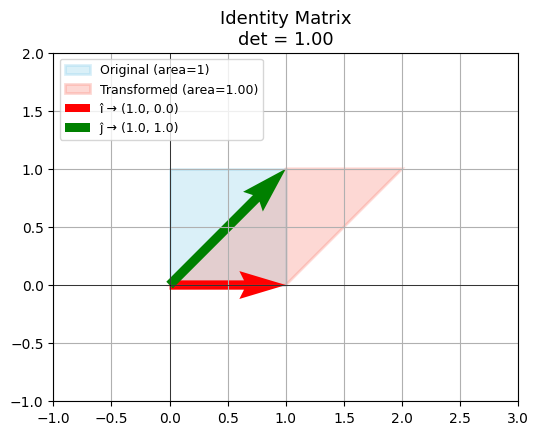

In [7]:
def plot_transform(matrix, title="Linear Transform", ax=None):
    """
    視覺化一個 2×2 矩陣對單位正方形的變換效果。
    
    原理：
    單位正方形的四個頂點是 (0,0), (1,0), (1,1), (0,1)
    經過矩陣 M 變換後，每個頂點 v 變成 M @ v
    變換後的面積 = |det(M)| × 原面積
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    M = np.array(matrix, dtype=float)
    
    # 單位正方形的四個頂點
    square = np.array([
        [0, 0],
        [1, 0],
        [1, 1],
        [0, 1]
    ])
    
    # 對每個頂點施加變換：(M @ v.T).T
    transformed = (M @ square.T).T
    
    # 畫原始正方形（淺藍色）
    original_patch = plt.Polygon(square, alpha=0.3, color='skyblue', 
                                  edgecolor='blue', linewidth=2, label='Original (area=1)')
    ax.add_patch(original_patch)
    
    # 畫變換後的平行四邊形（橘色）
    det_val = np.linalg.det(M)
    transformed_patch = plt.Polygon(transformed, alpha=0.3, color='salmon',
                                     edgecolor='red', linewidth=2, 
                                     label=f'Transformed (area={abs(det_val):.2f})')
    ax.add_patch(transformed_patch)
    
    # 畫基底向量 î 和 ĵ（變換後）
    ax.quiver(0, 0, M[0,0], M[1,0], angles='xy', scale_units='xy', scale=1, 
              color='red', width=0.02, label=f'î → ({M[0,0]:.1f}, {M[1,0]:.1f})')
    ax.quiver(0, 0, M[0,1], M[1,1], angles='xy', scale_units='xy', scale=1, 
              color='green', width=0.02, label=f'ĵ → ({M[0,1]:.1f}, {M[1,1]:.1f})')
    
    # 設定坐標軸
    all_pts = np.vstack([square, transformed])
    margin = 1
    ax.set_xlim(all_pts[:,0].min() - margin, all_pts[:,0].max() + margin)
    ax.set_ylim(all_pts[:,1].min() - margin, all_pts[:,1].max() + margin)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f"{title}\ndet = {det_val:.2f}", fontsize=13)
    
    return ax

# 測試：單位矩陣（什麼都不做）
plot_transform([[1, 0], [0, 1]], title="Identity Matrix")
plt.show()

---
## Part 3：行列式的三種情境

### 理論回顧

| det(M) 的值 | 幾何意義 |
|---|---|
| det > 0 | 面積被縮放，方向不變 |
| det < 0 | 面積被縮放，方向翻轉（像照鏡子）|
| det = 0 | 空間被壓扁（降維），面積變成 0 |

讓我們一次看三種情況：

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  original_patch = plt.Polygon(square, alpha=0.3, color='skyblue',
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  transformed_patch = plt.Polygon(transformed, alpha=0.3, color='salmon',


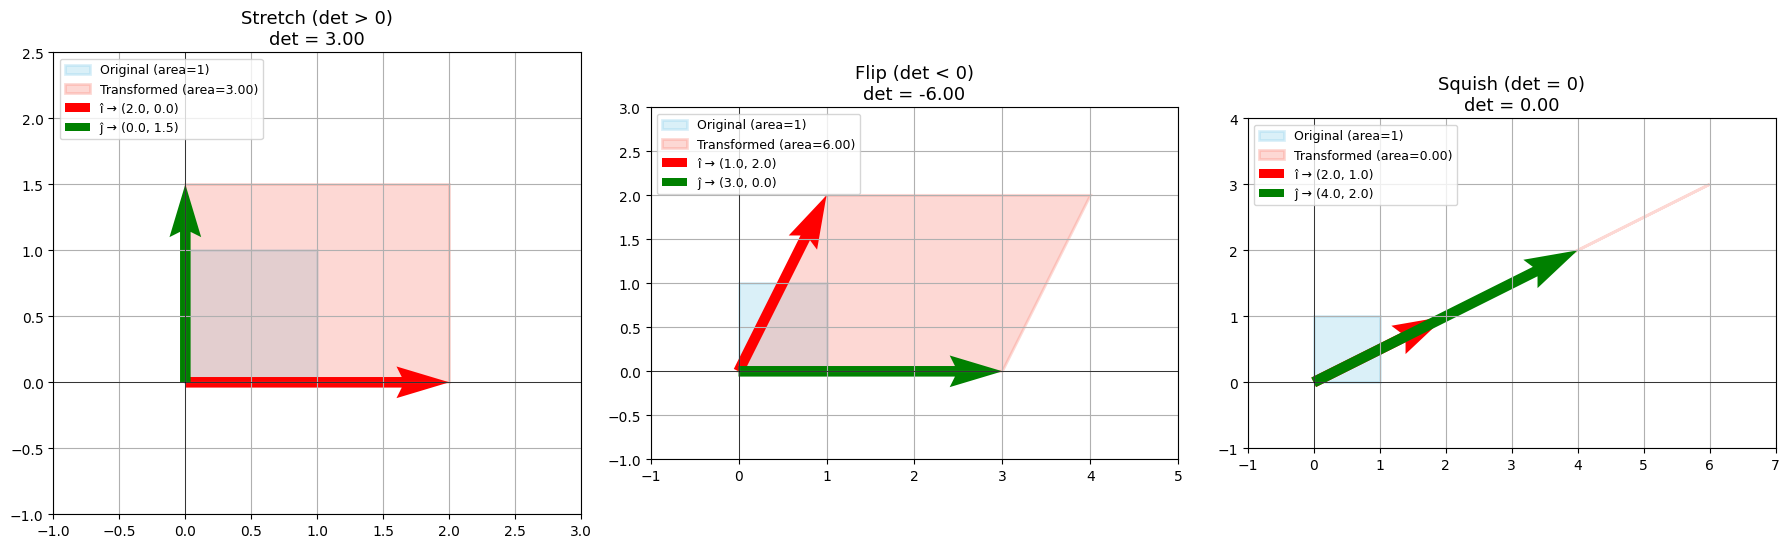

det(Stretch) = 3.00
det(Flip) = -6.00
det(Squish) = 0.00


In [8]:
# === 三種情境對比 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 情境 1：det > 0（拉伸，方向不變）
plot_transform([[2, 0], [0, 1.5]], title="Stretch (det > 0)", ax=axes[0])

# 情境 2：det < 0（翻轉！ĵ 跑到 î 的右邊 → 左邊）
plot_transform([[1, 3], [2, 0]], title="Flip (det < 0)", ax=axes[1])

# 情境 3：det = 0（壓扁成一條線）
# 注意：兩個 column 成比例 → 線性相依 → 壓扁
plot_transform([[2, 4], [1, 2]], title="Squish (det = 0)", ax=axes[2])

plt.tight_layout()
plt.show()

# 印出行列式值讓你對照
for name, M in [("Stretch", [[2,0],[0,1.5]]), 
                ("Flip", [[1,3],[2,0]]), 
                ("Squish", [[2,4],[1,2]])]:
    print(f"det({name}) = {np.linalg.det(np.array(M)):.2f}")

---
## Part 4：動手練習

試試自己改矩陣的值，觀察：
1. 把對角線的值調大，面積怎麼變？
2. 讓兩個 column 越來越接近（線性相依），det 趨近什麼？
3. 交換兩個 column，det 的正負號怎麼變？

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  original_patch = plt.Polygon(square, alpha=0.3, color='skyblue',
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  transformed_patch = plt.Polygon(transformed, alpha=0.3, color='salmon',


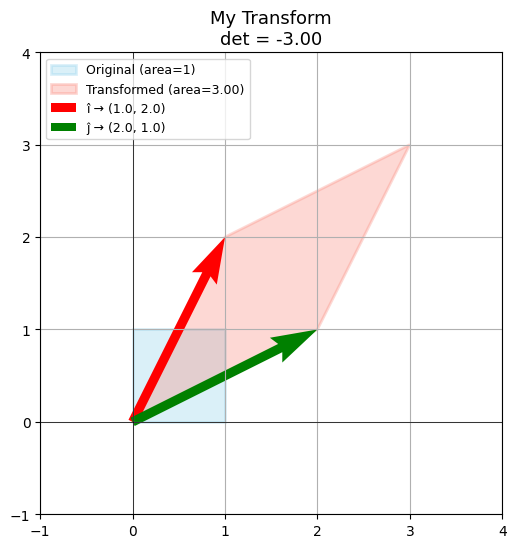

In [33]:
# === 練習區：修改這裡的矩陣，然後執行 cell 看效果！ ===

my_matrix = [
    [1, 2],
    [2, 1]
]  # ← 試試改這些數字！

plot_transform(my_matrix, title="My Transform")
plt.show()

* 對角線條大，面積等比放大。
* 兩個 column 越來越接近，面積越來越小直到線性相依，面積為0，超過 0 後 det 開始變為負數，det 從正數 → 經過 0（兩者重合，線性相依）→ 變成負數。
* 交換兩個 column 相當於翻轉，翻轉情況下 det 正負號轉換，交換 column 後的 det=−原本的 det。

---
## Part 5：det(AB) = det(A) × det(B) 的視覺驗證

### 理論

這是行列式最漂亮的性質之一。直覺是：
- 變換 A 把面積縮放了 |det(A)| 倍
- 變換 B 把面積縮放了 |det(B)| 倍
- 先做 B 再做 A，面積總共被縮放了 |det(A)| × |det(B)| 倍

下面我們用三張圖來驗證：原始 → 做完 B → 再做 A

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  original_patch = plt.Polygon(square, alpha=0.3, color='skyblue',
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_76185/2186736797.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  transformed_patch = plt.Polygon(transformed, alpha=0.3, color='salmon',


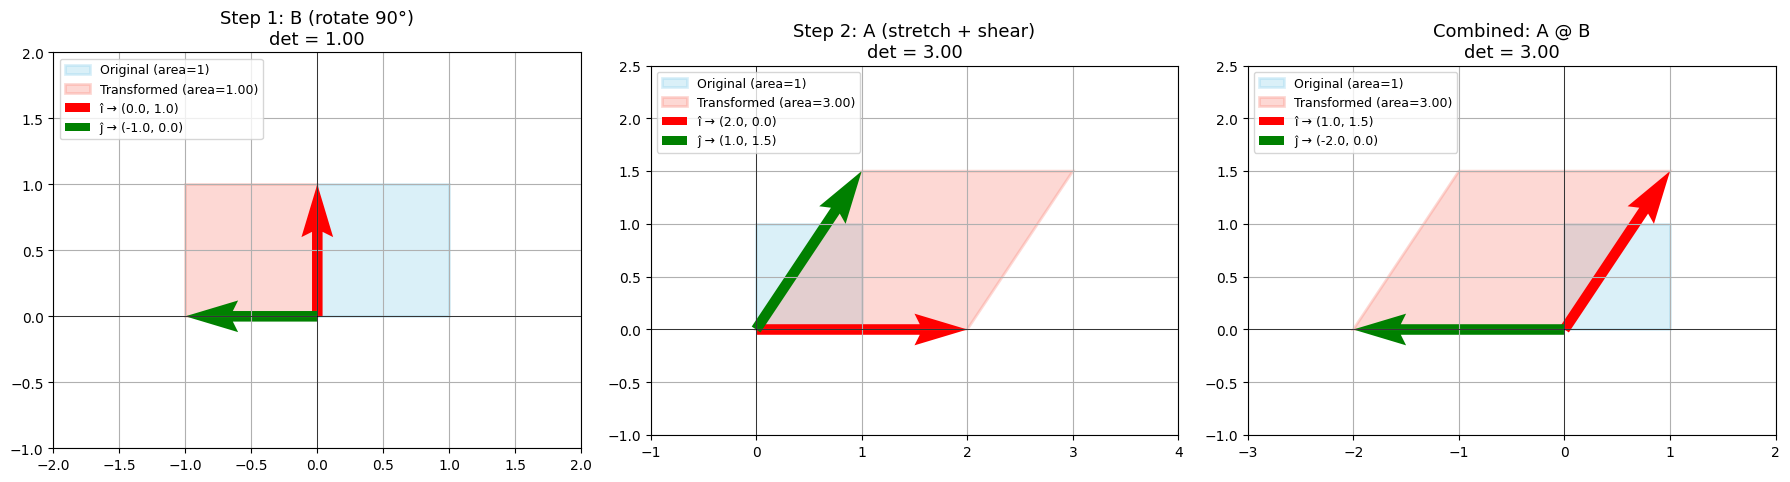

det(A)  = 3.0000
det(B)  = 1.0000
det(AB) = 3.0000
det(A) × det(B) = 3.0000

✓ det(AB) == det(A) × det(B): True


In [34]:
# === det(AB) = det(A) * det(B) 視覺驗證 ===

A = np.array([[2, 1], [0, 1.5]])  # 拉伸 + 剪切
B = np.array([[0, -1], [1, 0]])   # 90° 旋轉
AB = A @ B                         # 複合變換

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_transform(B, title="Step 1: B (rotate 90°)", ax=axes[0])
plot_transform(A, title="Step 2: A (stretch + shear)", ax=axes[1])
plot_transform(AB, title="Combined: A @ B", ax=axes[2])

plt.tight_layout()
plt.show()

# 數值驗證
det_A = np.linalg.det(A)
det_B = np.linalg.det(B)
det_AB = np.linalg.det(AB)

print(f"det(A)  = {det_A:.4f}")
print(f"det(B)  = {det_B:.4f}")
print(f"det(AB) = {det_AB:.4f}")
print(f"det(A) × det(B) = {det_A * det_B:.4f}")
print(f"\n✓ det(AB) == det(A) × det(B): {np.isclose(det_AB, det_A * det_B)}")

---
## Part 6：3D 行列式 — 體積的縮放

### 理論

在 3D 中，行列式衡量的是**體積的縮放因子**。
單位立方體經過 3×3 矩陣變換後，變成一個「平行六面體 (parallelepiped)」，
它的體積 = |det(M)| × 原體積。

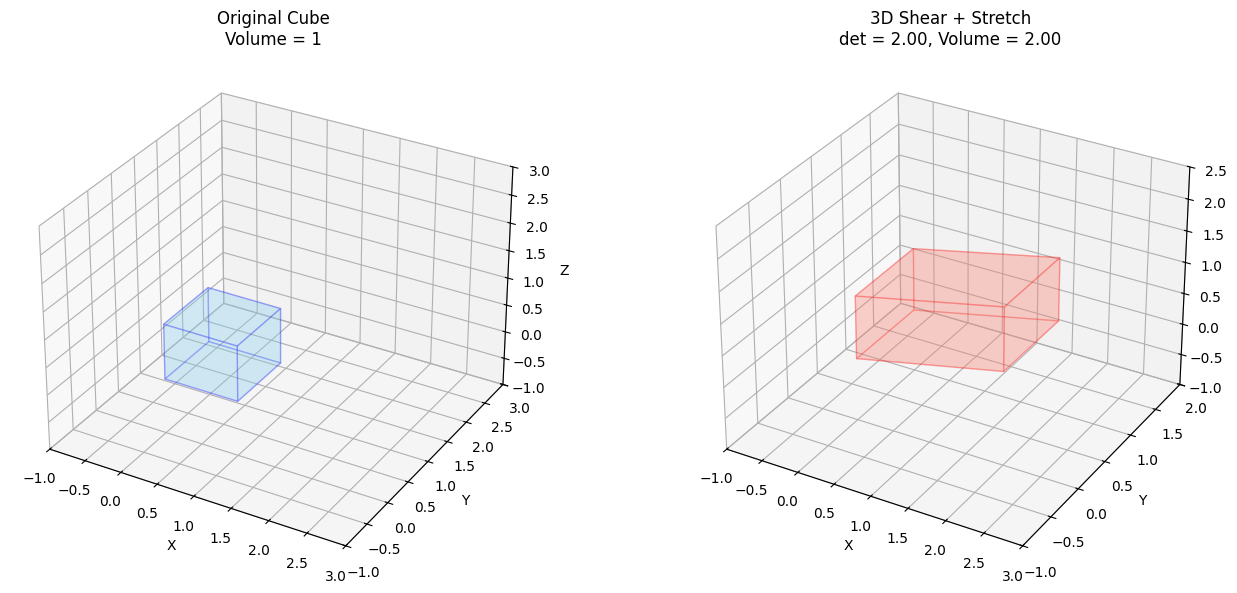

det = 2.00
→ x 方向拉伸 2 倍，體積變成 2 倍


In [35]:
# === 3D 行列式：體積的縮放 ===

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_3d_transform(matrix, title="3D Transform"):
    M = np.array(matrix, dtype=float)
    
    # 單位立方體的 8 個頂點
    cube_vertices = np.array([
        [0,0,0], [1,0,0], [1,1,0], [0,1,0],  # 底面
        [0,0,1], [1,0,1], [1,1,1], [0,1,1]   # 頂面
    ])
    
    # 變換
    transformed = (M @ cube_vertices.T).T
    
    # 定義 6 個面（用頂點索引）
    faces_idx = [
        [0,1,2,3], [4,5,6,7],  # 底、頂
        [0,1,5,4], [2,3,7,6],  # 前、後
        [0,3,7,4], [1,2,6,5]   # 左、右
    ]
    
    fig = plt.figure(figsize=(14, 6))
    
    # 原始立方體
    ax1 = fig.add_subplot(121, projection='3d')
    faces_orig = [[cube_vertices[i] for i in f] for f in faces_idx]
    ax1.add_collection3d(Poly3DCollection(faces_orig, alpha=0.2, 
                                           facecolor='skyblue', edgecolor='blue'))
    ax1.set_xlim(-1, 3); ax1.set_ylim(-1, 3); ax1.set_zlim(-1, 3)
    ax1.set_title("Original Cube\nVolume = 1")
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    
    # 變換後
    ax2 = fig.add_subplot(122, projection='3d')
    faces_trans = [[transformed[i] for i in f] for f in faces_idx]
    det_val = np.linalg.det(M)
    ax2.add_collection3d(Poly3DCollection(faces_trans, alpha=0.2, 
                                           facecolor='salmon', edgecolor='red'))
    all_pts = transformed
    margin = 1
    ax2.set_xlim(all_pts[:,0].min()-margin, all_pts[:,0].max()+margin)
    ax2.set_ylim(all_pts[:,1].min()-margin, all_pts[:,1].max()+margin)
    ax2.set_zlim(all_pts[:,2].min()-margin, all_pts[:,2].max()+margin)
    ax2.set_title(f"{title}\ndet = {det_val:.2f}, Volume = {abs(det_val):.2f}")
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()

# 試試一個 3D 剪切變換
M_3d = [
    [2,  0, 0],
    [0,  1, 0],
    [0.5, 0, 1]
]
plot_3d_transform(M_3d, title="3D Shear + Stretch")
print(f"det = {np.linalg.det(np.array(M_3d)):.2f}")
print("→ x 方向拉伸 2 倍，體積變成 2 倍")